# Module 3: Anomaly Detection in Urban Traffic (Variational Autoencoder Approach)

## Overview

This module leverages deep learning to detect unusual traffic patterns using a VAE trained on LSTM-predicted and true vehicle count time series.
- Inputs: Output CSV from Module 2 (`lstm_predicted_vehicles.csv`)
- Method: Train a VAE on normal sequences and detect anomalies by reconstruction error
- Outputs: Per-frame anomaly scores and flags for downstream dynamic control/reports

### Why a VAE?
- VAEs model "normal" data, so high reconstruction error flags abnormal/novel patterns (e.g., crashes, heavy jams, events)

---




## 1. Data Loading & Visualization

Upload/place `lstm_predicted_vehicles.csv` in the workspace.


   frame_idx  true_vehicles  predicted_vehicles
0          0            0.0            5.250742
1          1           10.0            4.762431
2          2            6.0            5.469113
3          3            0.0            5.461291
4          4            5.0            4.819744
Records: (9980, 3)


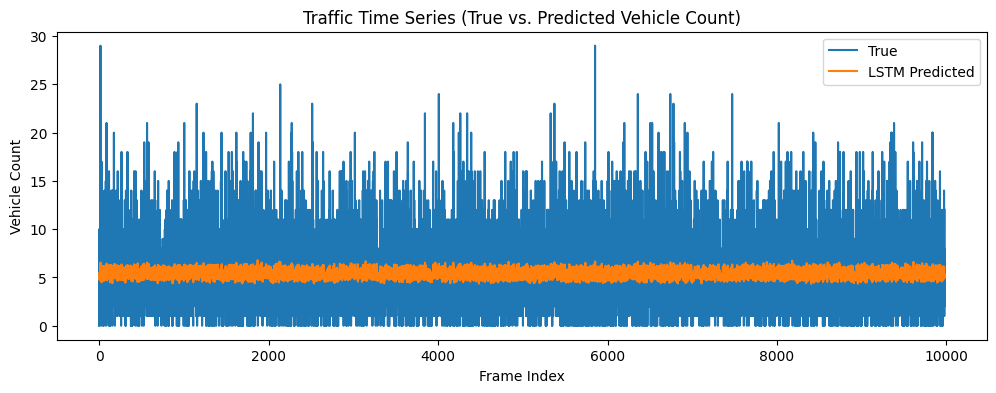

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/lstm_predicted_vehicles (1).csv')
print(df.head())
print(f"Records: {df.shape}")

plt.figure(figsize=(12,4))
plt.plot(df["true_vehicles"], label='True')
plt.plot(df["predicted_vehicles"], label='LSTM Predicted')
plt.title('Traffic Time Series (True vs. Predicted Vehicle Count)')
plt.xlabel("Frame Index")
plt.ylabel("Vehicle Count")
plt.legend()
plt.show()

## 2. Prepare Sliding Windows for VAE

- Like LSTM, VAE will model `window_size`-frame sequences as normal patterns.
- For simplicity, use only "true_vehicles" for anomaly detection (extend to multivariate if desired).

In [ ]:
from sklearn.preprocessing import MinMaxScaler

WINDOW_SIZE = 15  # Try 10-30; small enough for local patterns, large enough for context

data = df["true_vehicles"].values.reshape(-1,1)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

def create_windows(data, window=15):
    X = []
    for i in range(len(data)-window):
        X.append(data[i:i+window, 0])
    return np.array(X)

X = create_windows(data_scaled, window=WINDOW_SIZE)
print("Input shape for VAE:", X.shape)

Input shape for VAE: (9965, 15)


## 3. Split Data into Train (Normal) and Test (for evaluation)

- In real use, you’d mark or simulate anomalies in test. Here, we train on first 70-80%.

In [ ]:
split = int(0.8 * len(X))
X_train = X[:split]
X_test = X[split:]

print(f"Train windows: {X_train.shape}, Test windows: {X_test.shape}")

Train windows: (7972, 15), Test windows: (1993, 15)


## 4. Build and Train a Variational Autoencoder (VAE) in Keras

**VAE structure:**
- Encoder compresses input to latent space
- Decoder reconstructs original sequence
- VAE loss = reconstruction loss + KL divergence regularizer

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

LATENT_DIM = 4

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

def build_encoder(input_shape, latent_dim):
    encoder_inputs = layers.Input(shape=input_shape)
    x = layers.Dense(32, activation='relu')(encoder_inputs)
    x = layers.Dense(16, activation='relu')(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
    return encoder

def build_decoder(output_shape, latent_dim):
    latent_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(16, activation='relu')(latent_inputs)
    x = layers.Dense(32, activation='relu')(x)
    decoder_outputs = layers.Dense(output_shape, activation='sigmoid')(x)
    decoder = models.Model(latent_inputs, decoder_outputs, name="decoder")
    return decoder

class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(tf.square(data - reconstruction))
            kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

# Build models
encoder = build_encoder((WINDOW_SIZE,), LATENT_DIM)
decoder = build_decoder(WINDOW_SIZE, LATENT_DIM)
vae = VAE(encoder, decoder)
vae.compile(optimizer='adam')

vae.summary()

Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ ((None, 4), (None, 4), │         1,176 │
│                                 │ (None, 4))             │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 15)             │         1,119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,295 (8.96 KB)

 Trainable params: 2,295 (8.96 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training the VAE

Epoch 1/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - kl_loss: 7.4344e-04 - loss: 0.0621 - reconstruction_loss: 0.0613 - val_loss: 0.0251
Epoch 2/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - kl_loss: 2.4026e-05 - loss: 0.0226 - reconstruction_loss: 0.0226 - val_loss: 0.0220
Epoch 3/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - kl_loss: 5.1668e-06 - loss: 0.0212 - reconstruction_loss: 0.0212 - val_loss: 0.0211
Epoch 4/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - kl_loss: 2.2676e-06 - loss: 0.0204 - reconstruction_loss: 0.0204 - val_loss: 0.0205
Epoch 5/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - kl_loss: 1.2038e-06 - loss: 0.0199 - reconstruction_loss: 0.0199 - val_loss: 0.0201
Epoch 6/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - kl_loss: 6.3377e-07 - loss: 0.0196 - reconstruction_loss: 0.0196 - val_loss: 0.0199
Epoch 7/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 3.8018e-07 - loss: 0.0194 - reconstruction_loss: 0.0194 - val_loss: 0.0198
Epoch 8/40
125/125 ━━━━━━━━━━━━━━

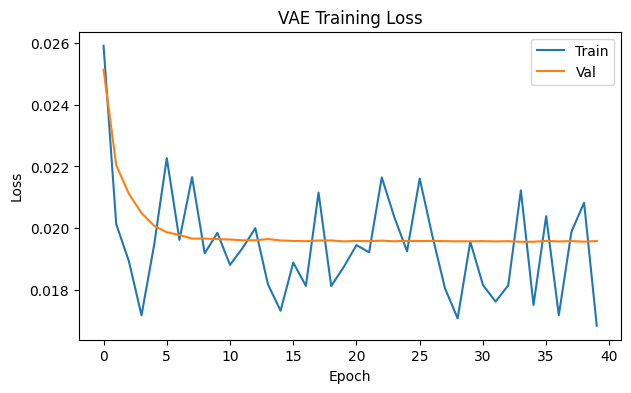

In [ ]:
# Instantiate and compile
vae = VAE(encoder, decoder)
vae.compile(optimizer='adam', loss='mse')

history = vae.fit(
    X_train, X_train,
    epochs=40,
    batch_size=64,
    shuffle=True,
    verbose=1,
    validation_data=(X_test, X_test)
)
plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 6. Evaluate Reconstruction Errors (Anomaly Scores)
- VAE's reconstruction error is high when the test window is "unusual."

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


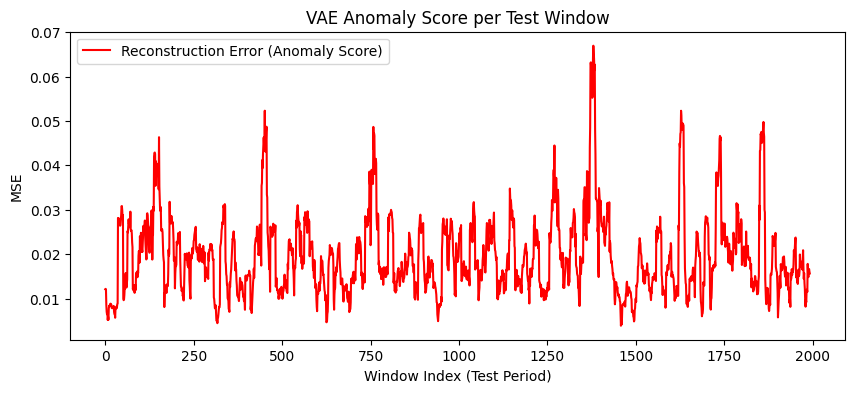

Max anomaly score: 0.067 -- Min: 0.004 -- Median: 0.018


In [ ]:
reconstructions = vae.predict(X_test)
mse = np.mean(np.square(X_test - reconstructions), axis=1)

plt.figure(figsize=(10,4))
plt.plot(mse, label="Reconstruction Error (Anomaly Score)", color="red")
plt.title("VAE Anomaly Score per Test Window")
plt.xlabel("Window Index (Test Period)")
plt.ylabel("MSE")
plt.legend()
plt.show()

print(f"Max anomaly score: {mse.max():.3f} -- Min: {mse.min():.3f} -- Median: {np.median(mse):.3f}")

## 7. Flag Anomalies

- Threshold: mark e.g. top 5% of errors as "anomaly" (or adjust by validation on human-labeled faults if available).

In [ ]:
threshold = np.percentile(mse, 95)  # Top 5% of errors
anomalies = mse > threshold

print(f"{anomalies.sum()} anomalies detected in test set ({len(anomalies)} windows)")

100 anomalies detected in test set (1993 windows)


## 8. Visualize Detected Anomalies in the Traffic Sequence
(superimpose on actual vehicle count)

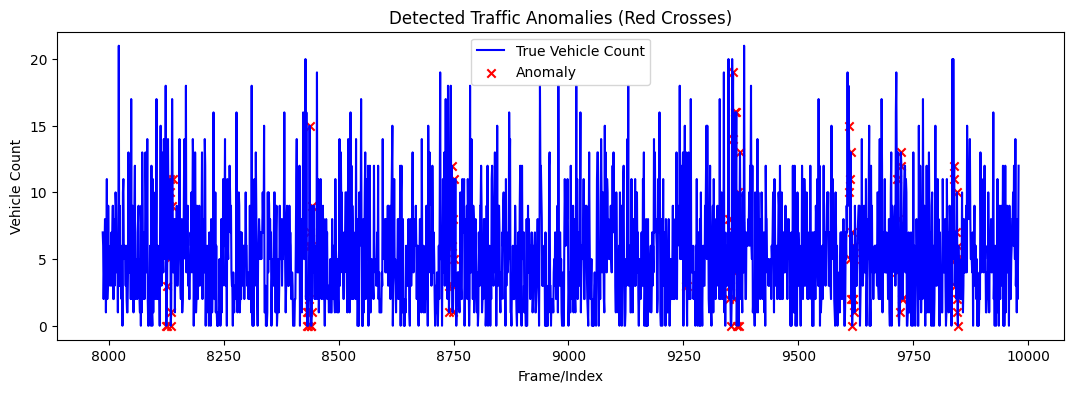

In [ ]:
plt.figure(figsize=(13,4))
plt.plot(np.arange(split+WINDOW_SIZE, len(df["true_vehicles"])), df["true_vehicles"].values[split+WINDOW_SIZE:], label='True Vehicle Count', c='blue')
plt.scatter(
    np.arange(split+WINDOW_SIZE, len(df["true_vehicles"]))[anomalies],
    df["true_vehicles"].values[split+WINDOW_SIZE:][anomalies],
    color='red', label='Anomaly', marker='x'
)
plt.title("Detected Traffic Anomalies (Red Crosses)")
plt.xlabel("Frame/Index")
plt.ylabel("Vehicle Count")
plt.legend()
plt.show()

## 9. Save Per-Frame Anomaly Scores for RL Module

Export anomaly labels and scores for downstream dynamic rerouting/traffic light RL.

In [ ]:
out_df = pd.DataFrame({
    "frame_idx": np.arange(split+WINDOW_SIZE, len(df["true_vehicles"])),
    "true_vehicle_count": df["true_vehicles"].values[split+WINDOW_SIZE:],
    "vae_anomaly_score": mse,
    "is_anomaly": anomalies.astype(int)
})
out_df.to_csv('vae_anomaly_results.csv', index=False)
print("Saved: vae_anomaly_results.csv")

Saved: vae_anomaly_results.csv


## Discussion

- This VAE detects abnormal traffic flow segments for real-time system triggers.
- Adjust the anomaly threshold according to requirements, or validate with ground truth.
- Exported `vae_anomaly_results.csv` is ready for downstream RL-based control/traffic intervention modules.

---

### References
- Kingma & Welling: Auto-Encoding Variational Bayes [arXiv:1312.6114](https://arxiv.org/abs/1312.6114)
- Anomaly Detection with Deep Learning [Keras Docs](https://keras.io/examples/timeseries/timeseries_anomaly_detection/)

---

*End of Module 3: Anomaly Detection via VAE*